# Visualization of feature importance among RF, XGBoost, GBDT
### 2025.01.29 sunyu 

GradientBoostingRegressor
#Gradient Boosting Hyperparameters 调整如下参数：
Boosting 框架参数
Gradient Boosting Hyperparameter #1: learning_rate
Gradient Boosting Hyperparameter #2: n_estimators
Gradient Boosting Hyperparameter #3: subsample
Gradient Boosting Hyperparameter #4: init
Gradient Boosting Hyperparameter #5: alpha
#树参数
Gradient Boosting Hyperparameter #6: max_depth
Gradient Boosting Hyperparameter #7: max_features
Gradient Boosting Hyperparameter #8: min_samples_split 
Gradient Boosting Hyperparameter #9: min_samples_leaf
Gradient Boosting Hyperparameter #10: max_leaf_nodes
Gradient Boosting Hyperparameter #11: verbose
The type of output to be printed when the model fits. The different values can be:
0: no output generated (default)
1: output generated for trees in certain intervas
>1: output generated for all trees
Gradient Boosting Hyperparameter #11: tol
Gradient Boosting Hyperparameter #12: random_state

# API
class sklearn.ensemble.GradientBoostingRegressor(*, loss='squared_error', learning_rate=0.1, n_estimators=100, subsample=1.0, criterion='friedman_mse', min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0, init=None, random_state=None, max_features=None, alpha=0.9, verbose=0, max_leaf_nodes=None, warm_start=False, validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)

In [4]:
#导入库
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.ensemble import GradientBoostingRegressor  #GBDT
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import missingno as msno

In [5]:
plt.rcParams['font.family'] = 'Times New Roman'
          
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# 读取CSV文件
data = pd.read_csv('20241128_sunyu.csv',encoding='gbk',header=0)

In [7]:
data

,煤田,矿区,采厚,面长,走向长,推进速度,开采方式,硬岩比,覆岩类型,抗压强度,采深,煤倾,导高
0,4,4,9.10,104.0,0.143045,0.194805,6,0.010,0.4,4.78,610.00,23.0,128.74
1,4,4,12.48,98.1,0.138282,0.194805,6,0.010,0.4,4.78,634.00,21.0,133.30
2,4,4,11.00,100.0,0.133027,0.194805,1,0.010,0.4,4.78,610.00,15.0,126.10
3,35,26,12.00,200.0,0.111348,0.233766,6,0.399,0.4,10.15,552.19,4.0,239.42
4,35,26,6.50,200.0,0.111348,0.233766,6,0.399,0.6,10.15,552.00,4.5,192.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,23,32,1.80,200.0,-0.047627,-0.038961,7,0.260,0.4,15.00,146.00,5.0,15.00
276,22,31,1.20,225.0,0.174084,-0.038961,5,0.660,0.6,35.00,120.00,6.8,31.00
277,34,51,4.00,136.0,0.082115,0.220779,7,0.210,0.4,15.00,350.00,7.0,35.50
278,34,51,3.60,150.0,0.154048,0.285714,7,0.250,0.4,15.00,359.00,7.5,30.20


In [8]:
# 获取特征和目标变量
X = data.drop('导高', axis=1) #'daogao'
y = data['导高']

In [ ]:
X

In [ ]:
y

In [9]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建随机森林回归器实例，并设置参数

In [10]:
rf = RandomForestRegressor(n_estimators = 79,criterion='squared_error',max_depth=5,min_samples_split=2,min_samples_leaf = 1,min_weight_fraction_leaf=0.0,
                           max_features=4, max_leaf_nodes=20, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=-1, 
                           random_state=8, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=20, monotonic_cst=None)

rf.fit(X, y)

RandomForestRegressor(max_depth=5, max_features=4, max_leaf_nodes=20,
                      max_samples=20, n_estimators=79, n_jobs=-1,
                      random_state=8)

# Gradient Boosting Regressor and GridSearch

In [11]:
gb = GradientBoostingRegressor(n_estimators = 80,learning_rate=0.02,subsample=0.7,alpha=0.1,max_features=5,max_depth=4,
                               min_samples_split=3,min_samples_leaf=14,max_leaf_nodes=5,random_state=3)  #learning_rate=0.02,
gb.fit(X,y)
#grid_search = GridSearchCV(estimator = gb, param_grid = param_grid,  scoring='neg_mean_squared_error',  n_jobs = -1)#cv = 5, verbose =2,'r2'
#gb.fit(X_train, y_train)

GradientBoostingRegressor(alpha=0.1, learning_rate=0.02, max_depth=4,
                          max_features=5, max_leaf_nodes=5, min_samples_leaf=14,
                          min_samples_split=3, n_estimators=80, random_state=3,
                          subsample=0.7)

In [13]:
# grid_search.best_params_

In [14]:
#xgb_regressor = xgb.XGBRegressor(learning_rate=0.067,n_estimators = 95,subsample=0.3,max_depth=9,random_state=3)
xgb_regressor =  XGBRegressor(learning_rate=0.067,n_estimators = 95,subsample=0.3,max_depth=9,random_state=3)
#xgb_regressor =  XGBRegressor(learning_rate=0.02,n_estimators = 60,subsample=0.4,max_depth=5,min_child_weight=26,gamma=8,reg_alpha=0.5,reg_lambda=5,random_state=3)
xgb_regressor.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.067, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=95, n_jobs=None,
             num_parallel_tree=None, random_state=3, ...)

In [15]:
# 获取RandomForest特征重要性并排序
          
rf_feature_importances = rf.feature_importances_
          
rf_sorted_indices = np.argsort(rf_feature_importances)[::-1]
          
rf_sorted_features = X_train.columns[rf_sorted_indices]
          
rf_sorted_importances = rf_feature_importances[rf_sorted_indices]

In [16]:
rf_sorted_importances

array([0.22872495, 0.20944499, 0.09763824, 0.09087726, 0.08342191,
       0.07702481, 0.06906995, 0.05424828, 0.04913774, 0.02631636,
       0.00867433, 0.00542116])

In [17]:
# 获取GDBT特征重要性并排序
          
gb_feature_importances = gb.feature_importances_
          
gb_sorted_indices = np.argsort(gb_feature_importances)[::-1]
          
gb_sorted_features = X_train.columns[gb_sorted_indices]
          
gb_sorted_importances =gb_feature_importances[gb_sorted_indices]

In [18]:
# 获取GDBT特征重要性并排序
          
xgb_feature_importances = xgb_regressor.feature_importances_
          
xgb_sorted_indices = np.argsort(xgb_feature_importances)[::-1]
          
xgb_sorted_features = X_train.columns[xgb_sorted_indices]
          
xgb_sorted_importances =xgb_feature_importances[xgb_sorted_indices]

In [19]:
# 创建一个DataFrame来保存所有模型的特征重要性
          
feature_importance_df = pd.DataFrame({
          
    "RandomForest_Feature": rf_sorted_features,
          
    "RandomForest_Importance": rf_sorted_importances,
          
    "GBDT_Feature": gb_sorted_features,
          
    "GBDT_Importance": gb_sorted_importances,
          
    "XGBoost_Feature": xgb_sorted_features,
          
    "XGBoost_Importance": xgb_sorted_importances,            
})

In [20]:
feature_importance_df

,RandomForest_Feature,RandomForest_Importance,GBDT_Feature,GBDT_Importance,XGBoost_Feature,XGBoost_Importance
0,采厚,0.228725,煤田,0.358401,煤田,0.198529
1,煤田,0.209445,采厚,0.356129,采厚,0.153223
2,采深,0.097638,面长,0.087116,抗压强度,0.108420
3,面长,0.090877,采深,0.056923,面长,0.101011
4,抗压强度,0.083422,开采方式,0.047625,开采方式,0.074038
5,煤倾,0.077025,走向长,0.045484,走向长,0.061260
6,硬岩比,0.069070,抗压强度,0.023566,采深,0.060281
7,矿区,0.054248,煤倾,0.009806,矿区,0.058781
8,走向长,0.049138,硬岩比,0.005941,推进速度,0.054976
9,开采方式,0.026316,矿区,0.005497,煤倾,0.050682


In [21]:
feature_importance_df.to_csv('featureimportance_RF_GBDT_XGBoost20250206.csv',index=False,encoding='ANSI')

In [22]:
feature_importance_df= pd.read_csv('featureimportance_RF_GBDT_XGBoost20250206.csv',encoding='gbk',header=0)

In [23]:
feature_importance_df

,RandomForest_Feature,RandomForest_Importance,GBDT_Feature,GBDT_Importance,XGBoost_Feature,XGBoost_Importance
0,采厚,0.228725,煤田,0.358401,煤田,0.198529
1,煤田,0.209445,采厚,0.356129,采厚,0.153223
2,采深,0.097638,面长,0.087116,抗压强度,0.108420
3,面长,0.090877,采深,0.056923,面长,0.101011
4,抗压强度,0.083422,开采方式,0.047625,开采方式,0.074038
5,煤倾,0.077025,走向长,0.045484,走向长,0.061260
6,硬岩比,0.069070,抗压强度,0.023566,采深,0.060281
7,矿区,0.054248,煤倾,0.009806,矿区,0.058781
8,走向长,0.049138,硬岩比,0.005941,推进速度,0.054976
9,开采方式,0.026316,矿区,0.005497,煤倾,0.050682


In [24]:
from matplotlib.font_manager import FontProperties
from matplotlib import rcParams
# 设置英文字体  
font_en = FontProperties(fname=r'C:\Windows\Fonts\times.ttf', size=8)

# 设置中文字体
font_cn = FontProperties(fname=r'C:\Windows\Fonts\simsun.ttc', size=8)

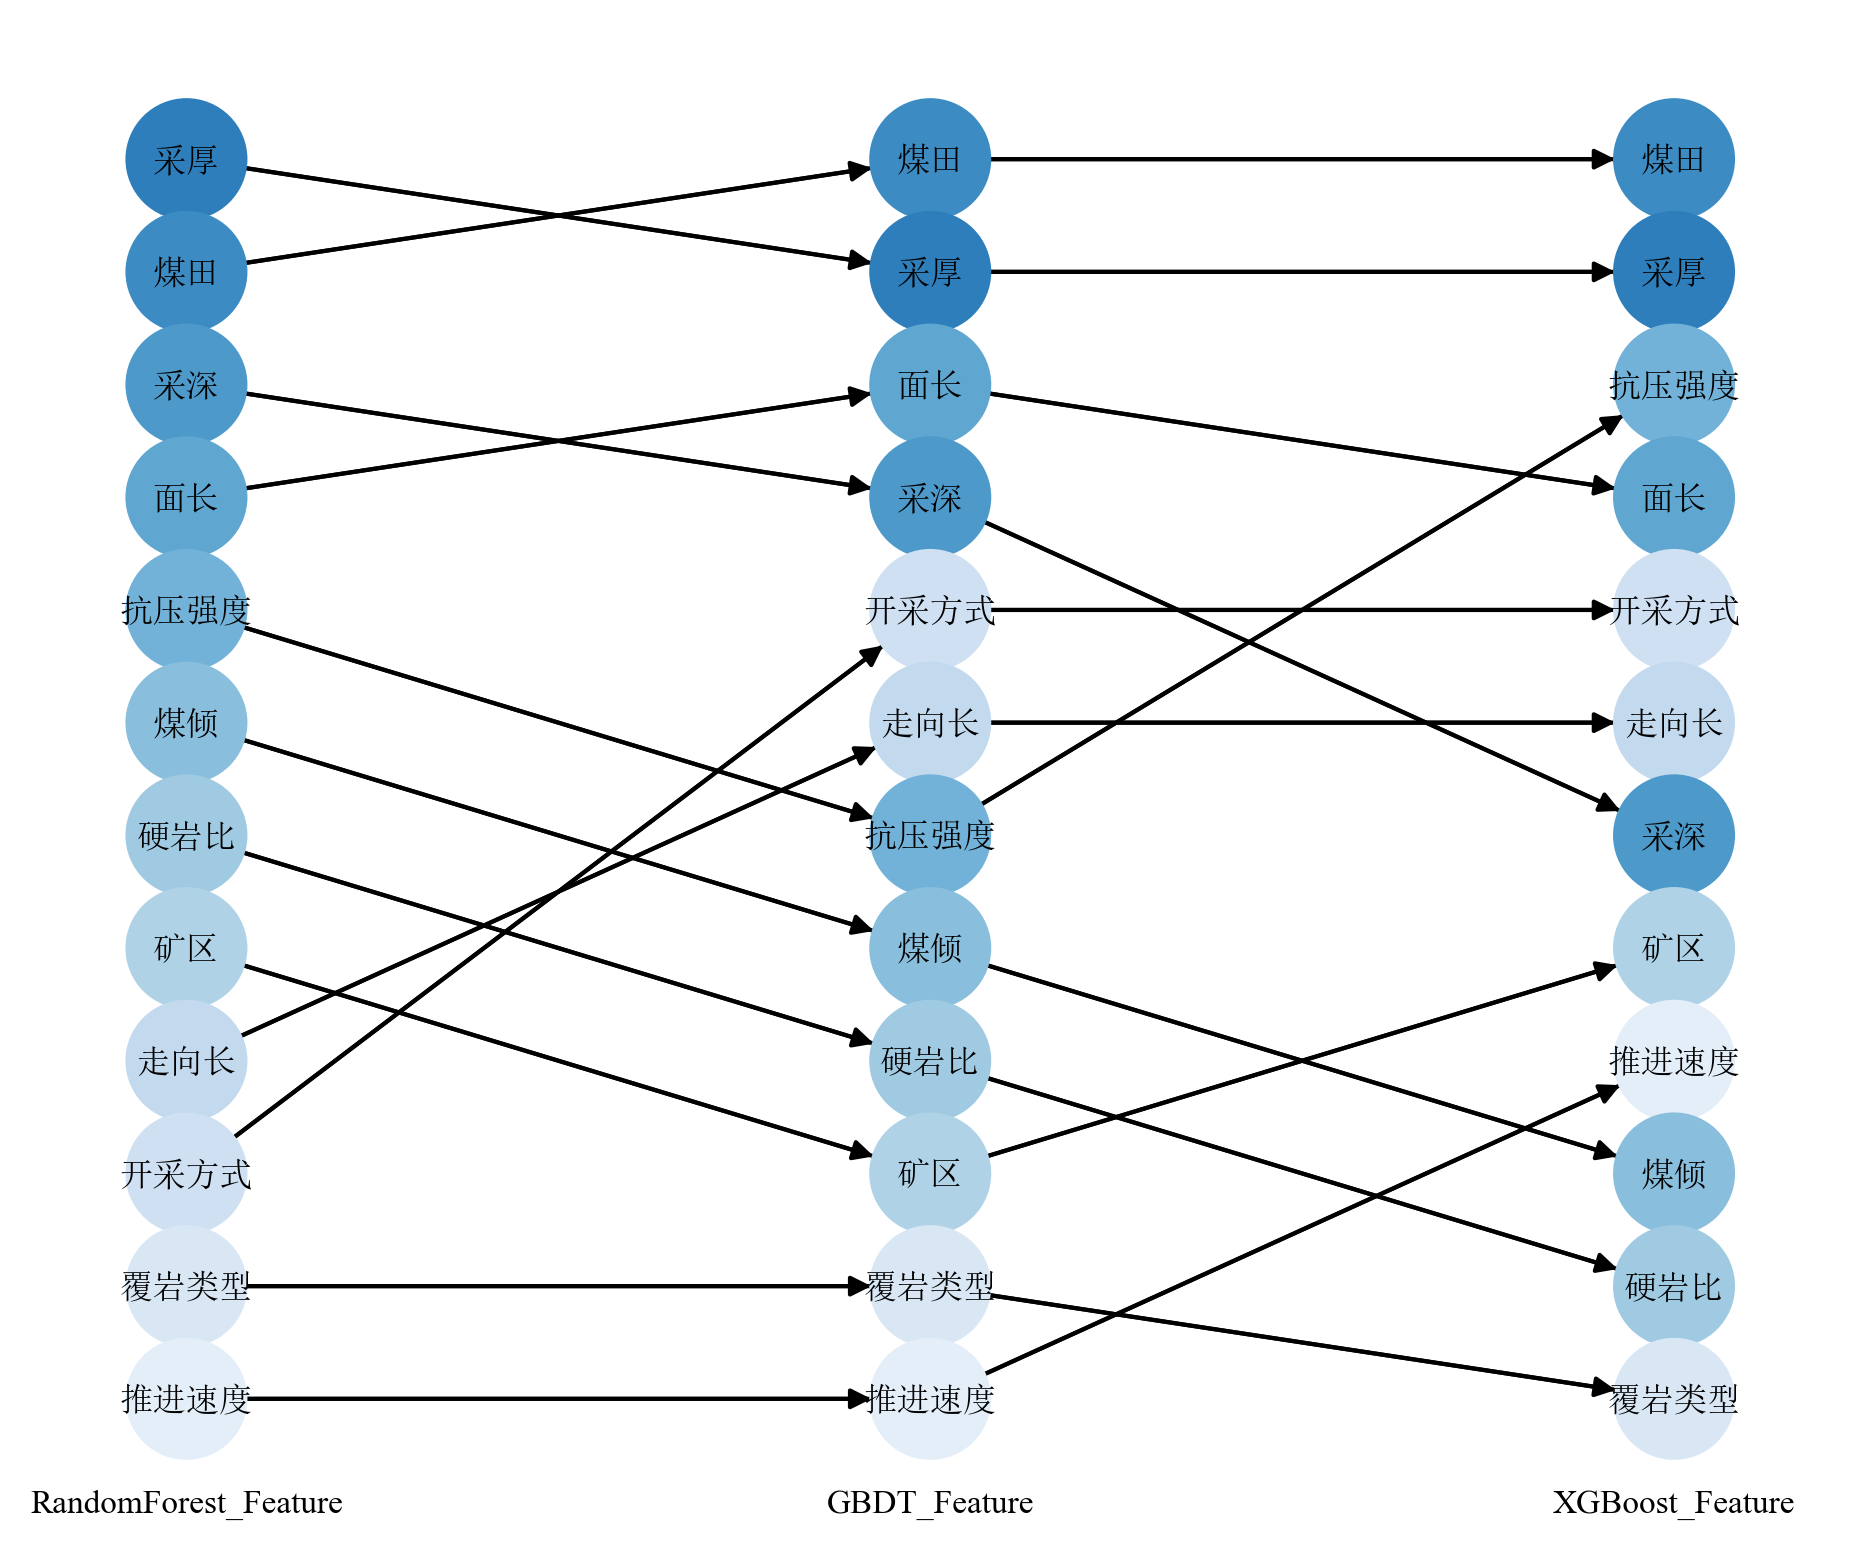

In [25]:
import networkx as nx
from matplotlib.font_manager import FontProperties   
font_en = FontProperties(fname=r'C:\Windows\Fonts\times.ttf', size=8)
font_cn = FontProperties(fname=r'C:\Windows\Fonts\simsun.ttc', size=8)
plt.rcParams['font.sans-serif'] = ['SimSun']
font = {'family' : 'SimSun',
        'english':'Times New Roman',
        'size'  : '9'}
# 设置 字体
#plt.rc('font', **font)

feature = feature_importance_df[['RandomForest_Feature', 'GBDT_Feature', 'XGBoost_Feature']]
          
plt.rcParams['font.family'] = 'SimSun'
#plt.rcParams['font.english'] = 'Times New Roman'        
plt.figure(figsize=(6, 5), dpi=300)
          

          
# 创建一个有向图
          
G = nx.DiGraph()
          
unique_features = pd.unique(feature.values.ravel('K'))
          

          
# 使用一个色系的渐变色
          
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(unique_features)))
          
feature_color_map = {feature_name: colors[i % len(colors)] for i, feature_name in enumerate(unique_features)}
          
pos = {}
          
for i, model in enumerate(feature.columns):
          
    for j, feature_name in enumerate(feature[model]):
          
        # 添加节点
          
        G.add_node(f'{model}_{feature_name}', label=feature_name)
          
        pos[f'{model}_{feature_name}'] = (i, -j) 
          
        if i > 0:
          
            previous_model = feature.columns[i - 1]
          
            for prev_j, prev_feature_name in enumerate(feature[previous_model]):
          
                if feature_name == prev_feature_name:
          
                    G.add_edge(f'{previous_model}_{prev_feature_name}', f'{model}_{feature_name}', color='black')  # 固定边的颜色为黑色
          
node_labels = nx.get_node_attributes(G, 'label')
          
node_colors = [feature_color_map[node_labels[node]] for node in G.nodes()]
          
nx.draw(G, pos, labels=node_labels, with_labels=True, node_color=node_colors, node_size=800, font_size=8)#fontproperties=font_cn
          
edges = G.edges()
          
nx.draw_networkx_edges(G, pos, edge_color='black', arrowstyle='-|>', arrowsize=10, width=1)
          
for i, model in enumerate(feature.columns):
          
    plt.text(i, -len(feature), model, horizontalalignment='center', fontsize=8, fontdict={'family':'Times New Roman'}) #,fontfamily='simsun' fontweight='bold',
          
plt.gca().set_axis_off()

          
#plt.title('Feature Ranking Comparison Across Models with Gradual Color Scheme and Styled Arrows')
         
plt.savefig('Feature Ranking Comparison_Styled Arrows20250428.tiff', dpi=300,bbox_inches='tight')
plt.savefig('Feature Ranking Comparison_Styled Arrows20250428.svg', dpi=300,bbox_inches='tight')
plt.savefig('Feature Ranking Comparison_Styled Arrows20250428.eps', dpi=300,bbox_inches='tight')
plt.savefig('Feature Ranking Comparison_Styled Arrows20250428.pdf', dpi=300,bbox_inches='tight')
#plt.savefig('Feature Ranking Comparison_Styled Arrows20250428.emf', dpi=300,bbox_inches='tight')
         
plt.show()